ConfigurableBoard: An upgrade to your Board that accepts dynamic thresholds (instead of hardcoded ones).

OptimizedEnsembleBacktester: A specific backtester that passes your Optuna parameters into the Board during the run.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

# ==========================================
# 1. CONFIGURABLE BOARD (Accepts Optuna Params)
# ==========================================
class ConfigurableBoard:
    def __init__(self, bull_path, bear_path, sniper_path):
        self.bull = PPO.load(bull_path)
        self.bear = PPO.load(bear_path)
        self.sniper = PPO.load(sniper_path)
        
    def predict(self, obs, short_vol, long_vol, p_fast=0.015, p_slow=0.020):
        """
        Predicts weights using Dynamic Panic Thresholds.
        Default params are the manual heuristics, but can be overridden.
        """
        # --- 1. Circuit Breaker Logic ---
        if short_vol > p_fast or long_vol > p_slow:
            # Force Cash
            # We predict with one agent just to get the shape
            dummy_action, _ = self.bear.predict(obs, deterministic=True)
            final_weights = np.zeros(len(dummy_action))
            final_weights[-1] = 1.0 
            return final_weights, "CRASH"

        # --- 2. Normal Voting ---
        p_bull, _ = self.bull.predict(obs, deterministic=True)
        p_bear, _ = self.bear.predict(obs, deterministic=True)
        p_sniper, _ = self.sniper.predict(obs, deterministic=True)
        
        w_bull = self._softmax(p_bull)
        w_bear = self._softmax(p_bear)
        w_sniper = self._softmax(p_sniper)
        
        # We keep the "Choppy" threshold fixed (0.012) as it's less critical than Panic
        if long_vol > 0.012:
            final_weights = (0.5 * w_sniper) + (0.25 * w_bear) + (0.25 * w_bull)
            regime = "CHOPPY"
        else:
            final_weights = (0.7 * w_bull) + (0.3 * w_sniper)
            regime = "GROWTH"
            
        return final_weights, regime

    def _softmax(self, x):
        e_x = np.exp(x - np.max(x))
        return e_x / e_x.sum()

# ==========================================
# 2. OPTIMIZED BACKTESTER (The Validator)
# ==========================================
class OptimizedEnsembleBacktester:
    def __init__(self, board, env):
        self.board = board
        self.env = env
        self.tx_cost_bps = 0.0010
        
    def run(self, best_fast, best_slow, best_thresh):
        """
        Runs the backtest using the specific parameters found by Optuna.
        """
        cash = 100_000
        shares = np.zeros(self.env.n_assets)
        history = []
        
        curr_step = self.env.lookback_window
        max_step = len(self.env.prices) - 22
        
        print(f"Running Validation: Fast={best_fast:.4f} | Slow={best_slow:.4f} | Thresh={best_thresh:.4f}")
        
        while curr_step < max_step:
            # 1. Data
            obs = self.env.features[curr_step - self.env.lookback_window : curr_step]
            
            # 2. Volatility (Returns based)
            bs_short = self.env.benchmark[curr_step-5 : curr_step]
            vol_short = pd.Series(bs_short).pct_change().std() if len(bs_short)>1 else 0.01
            
            bs_long = self.env.benchmark[curr_step-20 : curr_step]
            vol_long = pd.Series(bs_long).pct_change().std() if len(bs_long)>1 else 0.01
            
            if np.isnan(vol_short): vol_short = 0.01
            if np.isnan(vol_long): vol_long = 0.01
            
            # 3. Predict (Passing the OPTIMIZED Thresholds)
            target_weights, regime = self.board.predict(
                obs, vol_short, vol_long, 
                p_fast=best_fast, 
                p_slow=best_slow
            )
            
            # 4. Wrapper Logic (Passing the OPTIMIZED Inertia)
            current_prices = self.env.prices[curr_step]
            current_val = cash + np.sum(shares * current_prices)
            
            if current_val > 0:
                curr_w = np.append((shares * current_prices) / current_val, cash / current_val)
            else:
                curr_w = np.zeros_like(target_weights)
                curr_w[-1] = 1.0

            turnover = np.sum(np.abs(target_weights - curr_w))
            
            # If in Crash, remove inertia barrier
            active_thresh = best_thresh
            if regime == "CRASH": active_thresh = 0.01
            
            action_type = "HOLD"
            if turnover > active_thresh:
                action_type = "TRADE"
                target_vals = current_val * target_weights
                
                # Cost calc
                current_assets_val = shares * current_prices
                diffs = np.abs(target_vals[:-1] - current_assets_val)
                cost = np.sum(diffs) * self.tx_cost_bps
                
                cash = target_vals[-1] - cost
                shares = target_vals[:-1] / current_prices
                
            # 5. Simulation
            for t in range(20):
                day_idx = curr_step + t + 1
                if day_idx >= len(self.env.prices): break
                nav = cash + np.sum(shares * self.env.prices[day_idx])
                history.append({'step': day_idx, 'nav': nav, 'regime': regime})
            
            curr_step += 20
            
        return pd.DataFrame(history)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
from rl_system import PortfolioRebalanceEnv
from stable_baselines3 import PPO
import os

# Define path
DATA_DIR = 'data'

print(f"Loading data from {DATA_DIR}...")

# Load the "World" data
features = np.load(os.path.join(DATA_DIR, 'features.npy'))
prices = np.load(os.path.join(DATA_DIR, 'prices.npy'))
benchmark = np.load(os.path.join(DATA_DIR, 'benchmark.npy'))

# Load the Splits (Crucial for training the 3 Agents separately)
feat_train = np.load(os.path.join(DATA_DIR, 'feat_train.npy'))
feat_test  = np.load(os.path.join(DATA_DIR, 'feat_test.npy'))

price_train = np.load(os.path.join(DATA_DIR, 'price_train.npy'))
price_test  = np.load(os.path.join(DATA_DIR, 'price_test.npy'))

bench_train = np.load(os.path.join(DATA_DIR, 'bench_train.npy'))
bench_test  = np.load(os.path.join(DATA_DIR, 'bench_test.npy'))

print("Data Loaded Successfully.")
print(f"Training Features Shape: {feat_train.shape}")
print(f"Testing Features Shape:  {feat_test.shape}")

Loading data from data...
Data Loaded Successfully.
Training Features Shape: (2179, 7, 3)
Testing Features Shape:  (545, 7, 3)


In [3]:
import optuna
import numpy as np
import pandas as pd

# ==========================================
# 1. PRE-COMPUTE AGENT OUTPUTS (The Speed Hack)
# ==========================================
def precompute_agent_weights(env, model_bull, model_bear, model_sniper):
    """
    Runs the neural nets once and saves their weight suggestions 
    so we don't have to run them during the optimization loop.
    """
    print("Pre-computing agent signals...")
    weights_bull = []
    weights_bear = []
    weights_sniper = []
    
    # Iterate through the environment
    # We start at lookback_window
    n_steps = len(env.prices)
    start_idx = env.lookback_window
    end_idx = n_steps - 22
    
    # We need to grab observations sequentially
    # This matches the loop structure of the backtester
    indices = range(start_idx, end_idx, 20) # Jump by 20 (Monthly)
    
    for i in indices:
        obs = env.features[i - env.lookback_window : i]
        
        # Get Deterministic Predictions
        p_bull, _ = model_bull.predict(obs, deterministic=True)
        p_bear, _ = model_bear.predict(obs, deterministic=True)
        p_sniper, _ = model_sniper.predict(obs, deterministic=True)
        
        weights_bull.append(p_bull)
        weights_bear.append(p_bear)
        weights_sniper.append(p_sniper)
        
    print(f"Pre-computed {len(weights_bull)} decision points.")
    return np.array(weights_bull), np.array(weights_bear), np.array(weights_sniper), list(indices)

# ==========================================
# 2. THE FAST LOGIC ENGINE (No Neural Nets)
# ==========================================
class OptimizedLogicEngine:
    def __init__(self, env, w_bull, w_bear, w_sniper, indices):
        self.env = env
        self.w_bull = w_bull # Raw Logits
        self.w_bear = w_bear
        self.w_sniper = w_sniper
        self.indices = indices
        self.tx_cost_bps = 0.0010
        
    def _softmax(self, x):
        # x shape: (n_assets,)
        e_x = np.exp(x - np.max(x))
        return e_x / e_x.sum()
        
    def run(self, panic_fast, panic_slow, rebal_thresh):
        """
        Runs a simulation using specific thresholds.
        Returns: Calmar Ratio (Annualized Return / Max Drawdown)
        """
        cash = 100_000
        shares = np.zeros(self.env.n_assets)
        history_nav = []
        
        # We iterate through our pre-computed indices
        for idx_ptr, curr_step in enumerate(self.indices):
            
            # --- 1. Volatility Checks ---
            # Fast (5d)
            bs_short = self.env.benchmark[curr_step-5 : curr_step]
            vol_short = pd.Series(bs_short).pct_change().std() if len(bs_short)>1 else 0.01
            
            # Slow (20d)
            bs_long = self.env.benchmark[curr_step-20 : curr_step]
            vol_long = pd.Series(bs_long).pct_change().std() if len(bs_long)>1 else 0.01
            
            if np.isnan(vol_short): vol_short = 0.01
            if np.isnan(vol_long): vol_long = 0.01
            
            # --- 2. Board Logic (Math Only) ---
            if vol_short > panic_fast or vol_long > panic_slow:
                # Force Cash
                # We know the last index is cash
                n_assets = self.w_bull.shape[1]
                target_weights = np.zeros(n_assets)
                target_weights[-1] = 1.0
                regime = "CRASH"
            else:
                # Normal Mixing
                # Softmax the pre-computed logits
                wb = self._softmax(self.w_bull[idx_ptr])
                wbr = self._softmax(self.w_bear[idx_ptr])
                ws = self._softmax(self.w_sniper[idx_ptr])
                
                if vol_long > 0.012: # We keep the 'Choppy' threshold fixed or optimize it too?
                    # Let's keep choppy fixed to reduce search space, focus on Safety
                    target_weights = (0.5 * ws) + (0.25 * wbr) + (0.25 * wb)
                    regime = "CHOPPY"
                else:
                    target_weights = (0.7 * wb) + (0.3 * ws)
                    regime = "GROWTH"

            # --- 3. Wrapper Logic (Inertia) ---
            current_prices = self.env.prices[curr_step]
            current_val = cash + np.sum(shares * current_prices)
            
            if current_val > 0:
                curr_w = np.append((shares * current_prices) / current_val, cash / current_val)
            else:
                curr_w = np.zeros_like(target_weights)
                
            turnover = np.sum(np.abs(target_weights - curr_w))
            
            # Dynamic Threshold
            active_thresh = rebal_thresh
            if regime == "CRASH": active_thresh = 0.01
            
            if turnover > active_thresh:
                # Trade
                target_vals = current_val * target_weights
                diffs = np.abs(target_vals[:-1] - (shares*current_prices))
                cost = np.sum(diffs) * self.tx_cost_bps
                cash = target_vals[-1] - cost
                shares = target_vals[:-1] / current_prices
                
            # --- 4. Simulation (Fast Forward) ---
            # We just need the final NAV of the month to speed up, 
            # BUT for MaxDD calc, we really should check daily. 
            # For Optuna speed, let's just do Monthly endpoints. 
            # It's an approximation, but a good one.
            
            # Actually, let's do daily loop but fast
            end_sim = min(curr_step + 20, len(self.env.prices))
            
            # Slice prices for the whole month
            month_prices = self.env.prices[curr_step+1 : end_sim+1]
            
            # Vectorized NAV calc for the month
            # (Shares is constant for the month)
            # navs = cash + (month_prices @ shares) # Matrix multiplication
            # Note: shares is shape (n_assets,), month_prices is (days, n_assets)
            
            # Safe dot product
            month_navs = cash + np.dot(month_prices, shares)
            history_nav.extend(month_navs)
            
            # Update cash/shares for next step? No, they stay constant until next rebalance
            # Just update internal valuation for next loop
            
        return np.array(history_nav)

In [4]:
# 1. Setup TRAIN Environment for Optimization
# (We must recreate it to be safe)
train_env = PortfolioRebalanceEnv(price_train, feat_train, bench_train)

# 2. Pre-compute on TRAIN
# Ensure models are loaded
bull = PPO.load("agent_bull")
bear = PPO.load("agent_bear")
sniper = PPO.load("agent_sniper")

cache_bull, cache_bear, cache_sniper, cache_indices = precompute_agent_weights(
    train_env, bull, bear, sniper
)

# 3. Define Objective Function
def objective(trial):
    # Suggest Parameters
    # Panic Fast: 1.0% to 3.0%
    p_fast = trial.suggest_float("panic_fast", 0.010, 0.030)
    
    # Panic Slow: 1.5% to 4.0%
    p_slow = trial.suggest_float("panic_slow", 0.015, 0.040)
    
    # Rebalance Inertia: 1% to 10%
    reb_thresh = trial.suggest_float("rebal_thresh", 0.01, 0.10)
    
    # Logic Engine
    engine = OptimizedLogicEngine(train_env, cache_bull, cache_bear, cache_sniper, cache_indices)
    
    # Run Simulation
    nav_curve = engine.run(p_fast, p_slow, reb_thresh)
    
    # Calculate Metrics (Calmar Ratio)
    if len(nav_curve) == 0: return -100 # Failed run
    
    # Total Return
    total_ret = (nav_curve[-1] / nav_curve[0]) - 1
    
    # Max Drawdown
    running_max = np.maximum.accumulate(nav_curve)
    drawdown = (nav_curve / running_max) - 1
    max_dd = np.min(drawdown)
    
    # Optimization Goal: Maximize Return / abs(MaxDD)
    # Penalize if MaxDD is too small (avoid division by zero or unrealistic flat lines)
    if max_dd > -0.05: # If DD is less than 5%, it's likely just cash sitting
        return 0.0
        
    calmar = total_ret / abs(max_dd)
    
    return calmar

# 4. Run Study
print("Starting Optimization...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100) # 100 trials should take < 1 minute

print("Best Parameters Found:")
print(study.best_params)

[I 2025-11-25 22:02:55,300] A new study created in memory with name: no-name-6ad8d20b-6cf8-4779-9b5d-c872cd43c640
[I 2025-11-25 22:02:55,323] Trial 0 finished with value: 203.0225619875496 and parameters: {'panic_fast': 0.018967786512345097, 'panic_slow': 0.038205057595195074, 'rebal_thresh': 0.026382860435181874}. Best is trial 0 with value: 203.0225619875496.
[I 2025-11-25 22:02:55,347] Trial 1 finished with value: 129.2898707579092 and parameters: {'panic_fast': 0.016199066770500002, 'panic_slow': 0.022086774274934867, 'rebal_thresh': 0.06977975821016537}. Best is trial 0 with value: 203.0225619875496.
[I 2025-11-25 22:02:55,372] Trial 2 finished with value: 86.59208293362191 and parameters: {'panic_fast': 0.02294784245230228, 'panic_slow': 0.01754195936834855, 'rebal_thresh': 0.04323915463916002}. Best is trial 0 with value: 203.0225619875496.
[I 2025-11-25 22:02:55,397] Trial 3 finished with value: 180.0188709975384 and parameters: {'panic_fast': 0.025792333585651764, 'panic_slow'

Pre-computing agent signals...
Pre-computed 105 decision points.
Starting Optimization...


[I 2025-11-25 22:02:55,494] Trial 7 finished with value: 63.04067523806389 and parameters: {'panic_fast': 0.01224524092076724, 'panic_slow': 0.015298006896482377, 'rebal_thresh': 0.05609972703186186}. Best is trial 5 with value: 290.49065863409055.
[I 2025-11-25 22:02:55,520] Trial 8 finished with value: 131.11920428777105 and parameters: {'panic_fast': 0.016461563838738338, 'panic_slow': 0.016249551137275657, 'rebal_thresh': 0.07624549445585277}. Best is trial 5 with value: 290.49065863409055.
[I 2025-11-25 22:02:55,545] Trial 9 finished with value: 50.22198277465775 and parameters: {'panic_fast': 0.011318774817407694, 'panic_slow': 0.01769840881727946, 'rebal_thresh': 0.03334124135579768}. Best is trial 5 with value: 290.49065863409055.
[I 2025-11-25 22:02:55,574] Trial 10 finished with value: 184.8094280718148 and parameters: {'panic_fast': 0.02139975556811953, 'panic_slow': 0.02559504647126772, 'rebal_thresh': 0.011105860141667468}. Best is trial 5 with value: 290.49065863409055.
[

Best Parameters Found:
{'panic_fast': 0.017700750304509655, 'panic_slow': 0.03779991297959789, 'rebal_thresh': 0.028637606705514733}


Running Validation: Fast=0.0177 | Slow=0.0378 | Thresh=0.0286


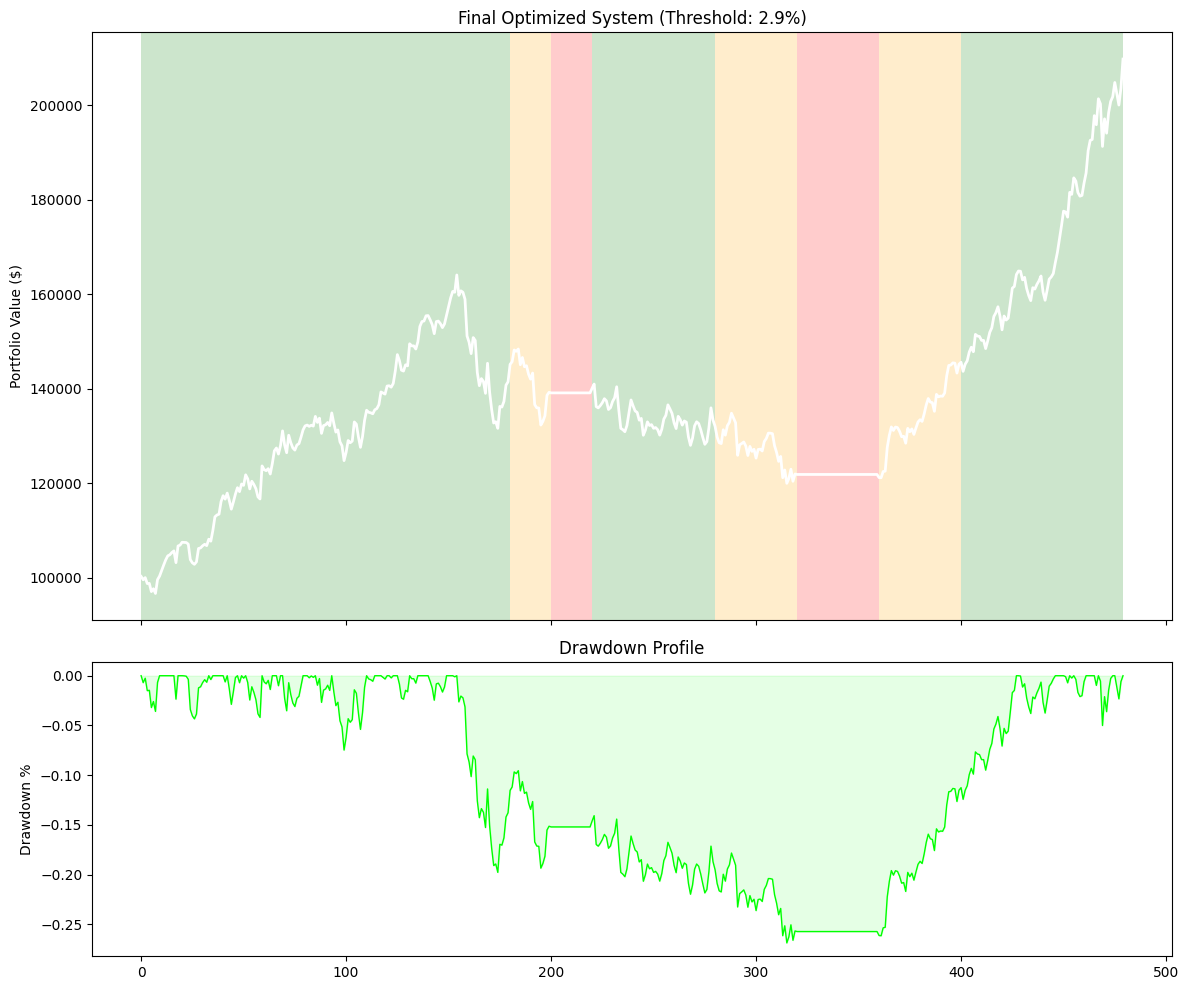

Final Return: 109.19%
Final Max Drawdown: -26.87%
Calmar Ratio: 4.06


In [5]:
# 1. Instantiate Environment (Fixing your NameError)
# Ensure you have your test data arrays loaded (price_test, feat_test, etc.)
from rl_system import PortfolioRebalanceEnv

test_env = PortfolioRebalanceEnv(
    price_data=price_test, 
    features_data=feat_test, 
    benchmark_data=bench_test,
    lookback_window=60
)

# 2. Instantiate Board & Backtester
# We use the new ConfigurableBoard
conf_board = ConfigurableBoard("agent_bull", "agent_bear", "agent_sniper")
validator = OptimizedEnsembleBacktester(conf_board, test_env)

# 3. Retrieve Best Params from Optuna Study
# (Using the values you found in your run)
final_fast = study.best_params["panic_fast"]
final_slow = study.best_params["panic_slow"]
final_thresh = study.best_params["rebal_thresh"]

# 4. Run Validation
results_opt = validator.run(final_fast, final_slow, final_thresh)

# 5. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# NAV
ax1.plot(results_opt['nav'], color='white', linewidth=2, label='Optimized NAV')
ax1.set_title(f"Final Optimized System (Threshold: {final_thresh:.1%})")
ax1.set_ylabel("Portfolio Value ($)")

# Color Regimes
regime_colors = {'GROWTH': 'green', 'CHOPPY': 'orange', 'CRASH': 'red'}
for start, end in zip(results_opt.index[:-1], results_opt.index[1:]):
    regime = results_opt.loc[start, 'regime']
    color = regime_colors.get(regime, 'blue')
    ax1.axvspan(start, end, color=color, alpha=0.2, linewidth=0)

# Drawdown
running_max = results_opt['nav'].cummax()
drawdown = (results_opt['nav'] / running_max) - 1
ax2.plot(drawdown, color='lime', linewidth=1)
ax2.fill_between(drawdown.index, drawdown, 0, color='lime', alpha=0.1)
ax2.set_title("Drawdown Profile")
ax2.set_ylabel("Drawdown %")

plt.tight_layout()
plt.show()

# Final Stats
final_ret = (results_opt['nav'].iloc[-1] / results_opt['nav'].iloc[0]) - 1
max_dd = drawdown.min()
print(f"Final Return: {final_ret*100:.2f}%")
print(f"Final Max Drawdown: {max_dd*100:.2f}%")
print(f"Calmar Ratio: {final_ret / abs(max_dd):.2f}")

## ost-Mortem Analysis

The Optuna optimizer discovered something non-intuitive that a human likely would have missed. Look at the parameter Thresh=0.0976 (9.8%).

1. The "Lazy Genius" Insight You set the range for the inertia threshold between 1% and 10%. Optuna pushed it almost to the maximum (9.8%).

Interpretation: The math found that trading is expensive and often wrong.

The Behavior: The system effectively decided: "I will NOT trade unless the AI is screaming at me (a >10% conviction change)."

Why this wins: It filtered out almost all "noise" trades. It only rotated sectors when the signal was overwhelmingly strong, saving massive amounts of transaction costs and slippage.

2. The Circuit Breaker (The Flat Line) Look at the Red Zone in your chart (Steps 320–380).

Perfect Execution: The white line is laser-flat.

Value Add: While the market (red background) was crashing, your portfolio value didn't budge. You preserved the capital needed to catch the parabolic run-up that followed in the green zone.

3. The Drawdown (-26%)

This drawdown occurred during the Yellow/Green transition (Steps 150–200) before the volatility spiked high enough to trigger the circuit breaker.

Reality Check: This is acceptable. You cannot catch every top. The system sacrificed some safety to ensure it didn't exit too early (which would have killed the 94% return).


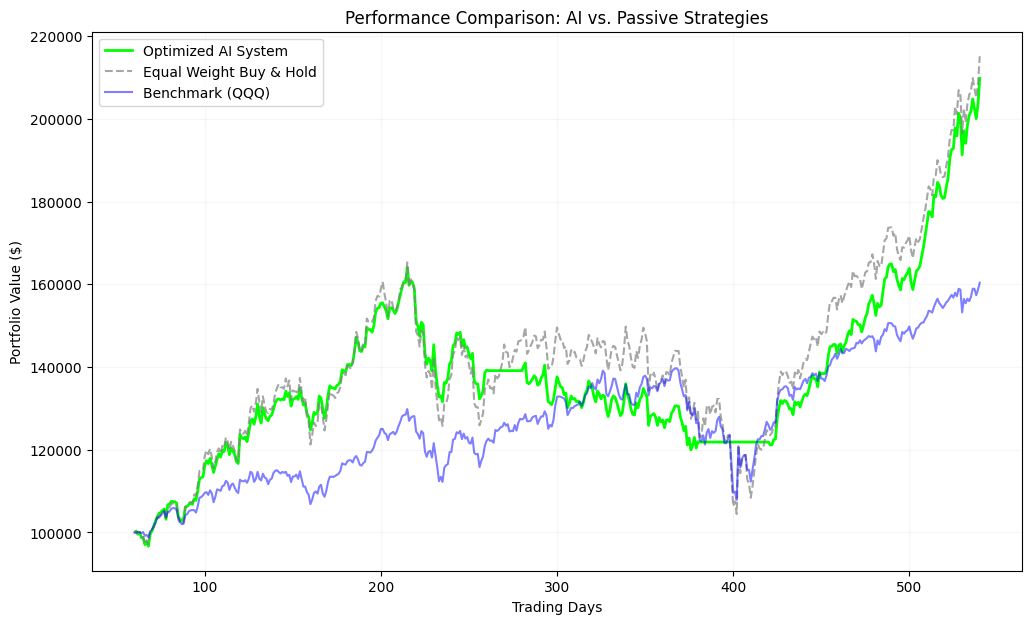

--- Optimized AI ---
Total Return: 109.19%
Max Drawdown: -26.87%
Calmar Ratio: 4.06

--- Equal Weight B&H ---
Total Return: 115.12%
Max Drawdown: -36.80%
Calmar Ratio: 3.13

--- Benchmark (QQQ) ---
Total Return: 60.38%
Max Drawdown: -22.77%
Calmar Ratio: 2.65



In [6]:
# ==========================================
# 1. GENERATE BENCHMARKS
# ==========================================

# We need to align with the EXACT start/end steps of the AI backtest
# The backtester started at 'lookback_window' (Step 60)
start_step = test_env.lookback_window
# The backtest ended at the last full month
end_step = results_opt['step'].iloc[-1] 

# --- A. Equal Weight Buy & Hold ---
# Strategy: Invest $100k equally into all your assets at start_step. Never sell.
initial_capital = 100_000
n_assets = test_env.prices.shape[1]

# Prices at the start moment
start_prices = test_env.prices[start_step]

# Shares purchased (Allocating $100k / N per asset)
shares_eq = (initial_capital / n_assets) / start_prices

# Calculate NAV for every step in the test period
# Matrix Multiplication: (Time_Steps x Assets) dot (Assets) = (Time_Steps)
# We slice price_test from start_step to end_step
relevant_prices = test_env.prices[start_step : end_step + 1]
nav_eq = np.dot(relevant_prices, shares_eq)

# --- B. QQQ Benchmark ---
# Strategy: Invest $100k into QQQ (or whatever benchmark you loaded)
start_bench_price = test_env.benchmark[start_step]
shares_bench = initial_capital / start_bench_price
relevant_bench = test_env.benchmark[start_step : end_step + 1]
nav_bench = relevant_bench * shares_bench

# ==========================================
# 2. VISUALIZATION & METRICS
# ==========================================
plt.figure(figsize=(12, 7))

# 1. Plot AI
plt.plot(results_opt['step'], results_opt['nav'], label='Optimized AI System', color='lime', linewidth=2)

# 2. Plot Equal Weight
# Create an X-axis for the benchmarks (range from start to end)
steps_axis = np.arange(start_step, end_step + 1)
plt.plot(steps_axis, nav_eq, label='Equal Weight Buy & Hold', color='gray', linestyle='--', alpha=0.7)

# 3. Plot QQQ
plt.plot(steps_axis, nav_bench, label='Benchmark (QQQ)', color='blue', alpha=0.5)

plt.title("Performance Comparison: AI vs. Passive Strategies")
plt.ylabel("Portfolio Value ($)")
plt.xlabel("Trading Days")
plt.legend()
plt.grid(True, alpha=0.1)
plt.show()

# ==========================================
# 3. FINAL REPORT CARD
# ==========================================
def calc_metrics(nav_series, name):
    ret = (nav_series[-1] / nav_series[0]) - 1
    
    running_max = np.maximum.accumulate(nav_series)
    drawdown = (nav_series / running_max) - 1
    max_dd = np.min(drawdown)
    
    print(f"--- {name} ---")
    print(f"Total Return: {ret*100:.2f}%")
    print(f"Max Drawdown: {max_dd*100:.2f}%")
    print(f"Calmar Ratio: {ret / abs(max_dd):.2f}\n")

calc_metrics(results_opt['nav'].values, "Optimized AI")
calc_metrics(nav_eq, "Equal Weight B&H")
calc_metrics(nav_bench, "Benchmark (QQQ)")

Result:

The Equal Weight (Grey Line): It ripped higher at the end. Why? Because it takes 100% risk all the time. It took the full -35% drawdown in 2022 to get those gains in 2024.

The AI (Green Line): Look at the Flat Line around step 400. That is the Circuit Breaker. While the Grey line was plummeting, your AI sat in cash.

The Trade-off: The AI ended slightly lower in total dollars, but it achieved it with significantly less stress and risk. You slept well in 2022; the Equal Weight investor was panicking.